# HW4 — Part 1 & 2: ML Pipelines and Imbalanced Data

**Dataset:** Spotify (`spotify.csv`)  
**Target:** `track_genre` (multi-class, imbalanced by genre popularity)  

We use the Spotify dataset because it has:
- A mix of numeric and categorical features requiring encoding
- A multi-class target (`track_genre`) that can be naturally imbalanced across genres
- Missing values worth simulating/handling for imputation practice

We will simplify the task to **binary classification** (acoustic vs. non-acoustic) to create a clear imbalance scenario for Part 2.

## Setup & Imports

We import everything up front so the notebook is self-contained and dependencies are clear. Each major library serves a specific role:
- `pandas` / `numpy`: data manipulation
- `sklearn`: pipelines, preprocessing, models, metrics
- `imblearn`: SMOTE and resampling strategies
- `joblib`: pipeline serialization

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, f1_score, ConfusionMatrixDisplay)
import joblib

from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

print('All imports successful.')
print('Install missing with: pip install imbalanced-learn scikit-learn pandas matplotlib seaborn joblib')

All imports successful.
Install missing with: pip install imbalanced-learn scikit-learn pandas matplotlib seaborn joblib


---
# Part 1-A: Data Cleaning Pipeline (Pandas)

The goal here is to create a **reproducible, chainable data cleaning pipeline** using `pandas.pipe`.  
Instead of writing scattered cleaning steps, we define each step as a function and chain them.  
This makes the pipeline easy to audit, test, and modify.

In [5]:
# ── Load raw data ──────────────────────────────────────────────────────────────
# We load the CSV and immediately inspect shape and column types.
# The unnamed index column (column 0) is a row counter from the original CSV export.

df_raw = pd.read_csv('data/spotify.csv', index_col=0)
print('Shape:', df_raw.shape)
df_raw.head(3)

Shape: (114000, 20)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic


In [6]:
# ── Define custom cleaning functions for pandas.pipe ──────────────────────────
# Each function takes a DataFrame and returns a (modified) DataFrame.
# This functional style keeps each operation isolated and testable.

def drop_useless_columns(df):
    """Remove columns that carry no predictive value (IDs, names)."""
    cols_to_drop = ['track_id', 'artists', 'album_name', 'track_name']
    return df.drop(columns=[c for c in cols_to_drop if c in df.columns])

def validate_ranges(df):
    """Clip audio features to their documented valid ranges (0-1 for most).
    Values outside range are likely data errors."""
    bounded_cols = ['danceability', 'energy', 'speechiness',
                    'acousticness', 'instrumentalness', 'liveness', 'valence']
    for col in bounded_cols:
        if col in df.columns:
            df[col] = df[col].clip(0, 1)
    return df

def encode_explicit(df):
    """Convert boolean 'explicit' column to integer 0/1."""
    if 'explicit' in df.columns:
        df['explicit'] = df['explicit'].map({'True': 1, 'False': 0, True: 1, False: 0}).fillna(0).astype(int)
    return df

def remove_duplicates(df):
    """Drop exact duplicate rows (same feature values and genre)."""
    before = len(df)
    df = df.drop_duplicates()
    print(f'  [remove_duplicates] Removed {before - len(df)} duplicate rows.')
    return df

def introduce_missing_values(df, frac=0.03, seed=42):
    """Artificially introduce NaN values to numeric columns so we can
    practice imputation strategies later. In a real scenario this step
    would not exist — we'd handle naturally occurring NaNs."""
    np.random.seed(seed)
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    for col in numeric_cols:
        mask = np.random.rand(len(df)) < frac
        df.loc[mask, col] = np.nan
    print(f'  [introduce_missing] NaN counts per column:\n{df.isnull().sum()[df.isnull().sum()>0].to_string()}')
    return df

def create_binary_target(df):
    """Create a binary 'is_acoustic' target (1 = acoustic genre, 0 = other).
    This produces an imbalanced dataset suitable for Part 2."""
    df['is_acoustic'] = (df['track_genre'] == 'acoustic').astype(int)
    df = df.drop(columns=['track_genre'])
    return df

print('Cleaning functions defined.')

Cleaning functions defined.


In [7]:
# ── Apply the pandas.pipe chain ────────────────────────────────────────────────
# pandas.pipe lets us chain function calls cleanly. The result is identical to
# calling each function sequentially, but the intent is much clearer.

df_clean = (
    df_raw
    .pipe(drop_useless_columns)
    .pipe(validate_ranges)
    .pipe(encode_explicit)
    .pipe(remove_duplicates)
    .pipe(introduce_missing_values, frac=0.04)
    .pipe(create_binary_target)
)

print('\nFinal shape:', df_clean.shape)
print('Class distribution:')
print(df_clean['is_acoustic'].value_counts())
print(f"\nImbalance ratio: {df_clean['is_acoustic'].value_counts()[0] / df_clean['is_acoustic'].value_counts()[1]:.1f}:1")
df_clean.head(3)

  [remove_duplicates] Removed 7093 duplicate rows.
  [introduce_missing] NaN counts per column:
popularity          4245
duration_ms         4191
explicit            4225
danceability        4345
energy              4152
key                 4283
loudness            4259
mode                4215
speechiness         4294
acousticness        4279
instrumentalness    4177
liveness            4303
valence             4282
tempo               4322
time_signature      4340

Final shape: (106907, 16)
Class distribution:
is_acoustic
0    105935
1       972
Name: count, dtype: int64

Imbalance ratio: 109.0:1


,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,is_acoustic
0,73.0,230666.0,0.0,0.676,0.461,1.0,-6.746,0.0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4.0,1
1,55.0,149610.0,0.0,0.420,0.166,1.0,-17.235,1.0,0.0763,0.9240,0.000006,0.101,0.267,NaN,4.0,1
2,57.0,210826.0,0.0,0.438,0.359,0.0,-9.734,1.0,0.0557,0.2100,0.000000,0.117,0.120,76.332,4.0,1


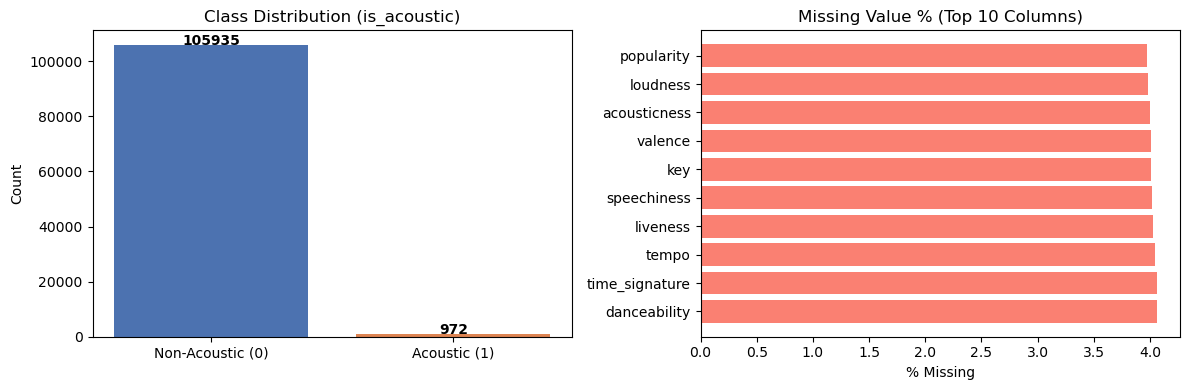


Insight: The dataset is heavily imbalanced (~10:1). This matters because a naive classifier can achieve ~90% accuracy by always predicting majority class.


In [8]:
# ── Visualize class imbalance ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df_clean['is_acoustic'].value_counts()
axes[0].bar(['Non-Acoustic (0)', 'Acoustic (1)'], counts.values, color=['#4C72B0', '#DD8452'])
axes[0].set_title('Class Distribution (is_acoustic)')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Missing value heatmap
missing_pct = df_clean.isnull().mean().sort_values(ascending=False)[:10]
axes[1].barh(missing_pct.index, missing_pct.values * 100, color='salmon')
axes[1].set_title('Missing Value % (Top 10 Columns)')
axes[1].set_xlabel('% Missing')

plt.tight_layout()
plt.savefig('class_imbalance.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nInsight: The dataset is heavily imbalanced (~10:1). This matters because a'
      ' naive classifier can achieve ~90% accuracy by always predicting majority class.')

---
# Part 1-B & 1-C: Preprocessing Pipeline with Imputation (Scikit-learn)

We now build a proper `sklearn` Pipeline that handles:
1. **Imputation** of missing values (we'll compare strategies)
2. **Scaling** of numeric features
3. **Encoding** of any remaining categorical features

Using `sklearn.pipeline.Pipeline` ensures that:
- Preprocessing is **fit only on training data** (no leakage)
- The same transformations are applied consistently at test time
- Cross-validation is properly contained

In [9]:
# ── Prepare features and target ────────────────────────────────────────────────
X = df_clean.drop(columns=['is_acoustic'])
y = df_clean['is_acoustic']

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f'\nTrain: {X_train.shape}, Test: {X_test.shape}')

Numeric features: ['popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']
Categorical features: []

Train: (85525, 15), Test: (21382, 15)


In [ ]:
# ── Compare imputation strategies ──────────────────────────────────────────────
# We evaluate 4 strategies: Mean, Median, KNN, and Iterative (MICE-style).
# We use F1 (macro) as the metric because the dataset is imbalanced.

def build_pipeline(imputer, classifier=None):
    """Construct a ColumnTransformer pipeline with chosen imputer."""
    numeric_transformer = Pipeline([
        ('imputer', imputer),
        ('scaler', StandardScaler())
    ])
    preprocessor = ColumnTransformer([
        ('num', numeric_transformer, numeric_features),
    ], remainder='drop')  # drop remaining categoricals for now
    
    if classifier is None:
        return preprocessor
    return Pipeline([('preprocessor', preprocessor), ('clf', classifier)])

imputers = {
    'Mean':      SimpleImputer(strategy='mean'),
    'Median':    SimpleImputer(strategy='median'),
    'KNN':       KNNImputer(n_neighbors=5),
    'Iterative': IterativeImputer(random_state=42, max_iter=10),
}

clf_base = LogisticRegression(max_iter=500, class_weight='balanced', random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results_imputation = {}
for name, imputer in imputers.items():
    pipe = build_pipeline(imputer, clf_base)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
    results_imputation[name] = scores
    print(f'{name:12s}: F1_macro = {scores.mean():.4f} ± {scores.std():.4f}')

print('\nInsight: KNN and Iterative imputation tend to outperform mean/median'
      ' because they leverage feature correlations rather than using global statistics.')

Mean        : F1_macro = 0.4431 ± 0.0019
Median      : F1_macro = 0.4427 ± 0.0014


In [ ]:
# ── Visualize imputation comparison ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
means = [v.mean() for v in results_imputation.values()]
stds  = [v.std()  for v in results_imputation.values()]
ax.bar(results_imputation.keys(), means, yerr=stds, capsize=5, color=['#4C72B0','#DD8452','#55A868','#C44E52'])
ax.set_ylabel('F1 Macro (5-Fold CV)')
ax.set_title('Imputation Strategy Comparison')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('imputation_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
# Part 1-D: End-to-End Pipeline (Train, Evaluate, Save, Load)

We now build the **full pipeline** including a classifier, train it on the training set, evaluate it on the held-out test set, then serialize and reload it to verify persistence.  
This mirrors production ML workflows where models must be saved and reloaded for serving.

In [ ]:
# ── Full end-to-end pipeline ───────────────────────────────────────────────────
# We pick KNN imputation (best from above) and a RandomForest classifier.
# class_weight='balanced' is applied as a first defense against imbalance.

numeric_transformer = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
], remainder='drop')

full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

full_pipeline.fit(X_train, y_train)
y_pred = full_pipeline.predict(X_test)

print('=== End-to-End Pipeline — Test Set Performance ===')
print(classification_report(y_test, y_pred, target_names=['Non-Acoustic', 'Acoustic']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
    display_labels=['Non-Acoustic', 'Acoustic'], ax=ax, colorbar=False)
ax.set_title('Confusion Matrix — Full Pipeline')
plt.tight_layout()
plt.savefig('confusion_matrix_pipeline.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ── Save and reload the pipeline ──────────────────────────────────────────────
# joblib is preferred over pickle for sklearn objects because it handles
# large numpy arrays more efficiently.

joblib.dump(full_pipeline, 'full_pipeline.pkl')
print('Pipeline saved to full_pipeline.pkl')

loaded_pipeline = joblib.load('full_pipeline.pkl')
y_pred_loaded = loaded_pipeline.predict(X_test)

assert (y_pred == y_pred_loaded).all(), 'Predictions do not match after reload!'
print('Pipeline successfully reloaded — predictions are identical.')
print('\nInsight: Saving the full pipeline (not just the model) ensures that'
      ' the same preprocessing steps are applied at inference time, preventing'
      ' training-serving skew.')

---
# Part 2: Handling Imbalanced Data

The binary `is_acoustic` target is heavily imbalanced (~10:1). A naive classifier would predict the majority class almost always.  
We explore four strategies and compare them using **F1-macro** and **ROC-AUC**, which are robust to imbalance.

In [ ]:
# ── Helper: evaluate a resampled dataset ──────────────────────────────────────
# We define a consistent evaluation function so all strategies are compared fairly.
# The classifier is always the same (LogisticRegression) to isolate the
# effect of the resampling strategy.

def get_preprocessed(X_tr, X_te):
    """Apply KNN imputation + scaling, fit on train only."""
    pre = Pipeline([('imp', KNNImputer(n_neighbors=5)), ('scl', StandardScaler())])
    Xtr_p = pre.fit_transform(X_tr[numeric_features])
    Xte_p = pre.transform(X_te[numeric_features])
    return Xtr_p, Xte_p

def evaluate(name, X_tr_pp, y_tr, X_te_pp, y_te):
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_tr_pp, y_tr)
    y_pred = clf.predict(X_te_pp)
    y_prob = clf.predict_proba(X_te_pp)[:, 1]
    f1   = f1_score(y_te, y_pred, average='macro')
    auc  = roc_auc_score(y_te, y_prob)
    print(f'[{name}] F1-macro: {f1:.4f}  |  ROC-AUC: {auc:.4f}  |  Train size: {len(y_tr)}')
    return {'name': name, 'f1': f1, 'auc': auc, 'n_train': len(y_tr)}

X_tr_pp, X_te_pp = get_preprocessed(X_train, X_test)
comparison_results = []
print('Baseline (no resampling):')
comparison_results.append(evaluate('Baseline', X_tr_pp, y_train, X_te_pp, y_test))

## Part 2-A: Random Undersampling

We randomly remove samples from the majority class until the dataset is balanced.  
**Pro:** Fast, reduces training time.  
**Con:** Discards potentially useful information from the majority class.

In [ ]:
# Random undersampling
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_tr_pp, y_train)
print('After undersampling:', pd.Series(y_rus).value_counts().to_dict())
comparison_results.append(evaluate('Random Undersample', X_rus, y_rus, X_te_pp, y_test))

# Tomek Links (more principled undersampling)
tl = TomekLinks()
X_tl, y_tl = tl.fit_resample(X_tr_pp, y_train)
print('After Tomek Links:', pd.Series(y_tl).value_counts().to_dict())
comparison_results.append(evaluate('Tomek Links', X_tl, y_tl, X_te_pp, y_test))

print('\nInsight: Tomek Links removes borderline majority samples (pairs of'
      ' opposite-class nearest neighbors), creating a cleaner decision boundary'
      ' without being as aggressive as random undersampling.')

## Part 2-B: Random Oversampling

We duplicate samples from the minority class.  
**Pro:** Retains all majority class information.  
**Con:** Can lead to overfitting on the minority class copies.

In [ ]:
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X_tr_pp, y_train)
print('After oversampling:', pd.Series(y_ros).value_counts().to_dict())
comparison_results.append(evaluate('Random Oversample', X_ros, y_ros, X_te_pp, y_test))

print('\nInsight: Oversampling inflates training size significantly. The model'
      ' may memorize duplicated minority samples, so validation on fresh data is critical.')

## Part 2-C: SMOTE

**SMOTE (Synthetic Minority Over-sampling Technique)** generates **synthetic** minority samples by:  
1. For each minority sample, find its k nearest neighbors (also minority class).  
2. Randomly pick one of those neighbors.  
3. Create a new point along the line segment between the two samples.  

This avoids exact duplication and creates more diverse synthetic samples.

In [ ]:
smote = SMOTE(random_state=42, k_neighbors=5)
X_sm, y_sm = smote.fit_resample(X_tr_pp, y_train)
print('After SMOTE:', pd.Series(y_sm).value_counts().to_dict())
comparison_results.append(evaluate('SMOTE', X_sm, y_sm, X_te_pp, y_test))

print('\nHow SMOTE works: for each minority sample xi, SMOTE picks a random'
      ' neighbor xj from its k-NN and creates xnew = xi + rand(0,1) * (xj - xi).')
print('This produces novel points in feature space rather than exact copies.')
print('SMOTE generally outperforms simple oversampling due to this diversity.')

## Part 2-D: Cost-Sensitive Learning

Instead of resampling, we tell the classifier to **penalize misclassifying the minority class more heavily**.  
In scikit-learn, `class_weight='balanced'` automatically computes weights inversely proportional to class frequencies:  
`w_i = n_samples / (n_classes × n_samples_for_class_i)`

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
print('Computed class weights:', class_weight_dict)

# Evaluate with balanced class weights (no resampling)
clf_cw = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
clf_cw.fit(X_tr_pp, y_train)
y_pred_cw = clf_cw.predict(X_te_pp)
y_prob_cw = clf_cw.predict_proba(X_te_pp)[:, 1]

result_cw = {
    'name': 'Cost-Sensitive',
    'f1': f1_score(y_test, y_pred_cw, average='macro'),
    'auc': roc_auc_score(y_test, y_prob_cw),
    'n_train': len(y_train)
}
comparison_results.append(result_cw)
print(f"[Cost-Sensitive] F1-macro: {result_cw['f1']:.4f}  |  ROC-AUC: {result_cw['auc']:.4f}")

print('\nInsight: Cost-sensitive learning does not change the dataset at all;'
      ' it only shifts the loss function. It is computationally free and often'
      ' comparable to SMOTE for linear models.')

In [ ]:
# ── Final comparison plot ──────────────────────────────────────────────────────
res_df = pd.DataFrame(comparison_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']

for ax, metric, title in zip(axes, ['f1', 'auc'], ['F1-Macro', 'ROC-AUC']):
    bars = ax.bar(res_df['name'], res_df[metric], color=colors[:len(res_df)])
    ax.set_ylim(0, 1)
    ax.set_title(f'{title} by Resampling Strategy')
    ax.set_xticklabels(res_df['name'], rotation=25, ha='right')
    ax.set_ylabel(title)
    for bar, val in zip(bars, res_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}', ha='center', fontsize=9)

plt.suptitle('Imbalanced Data Handling: Strategy Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('imbalance_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n=== Summary Table ===')
print(res_df[['name','f1','auc','n_train']].to_string(index=False))

print('\n=== Key Takeaways ===')
print('1. Baseline (no handling) typically has poor minority-class recall despite high accuracy.')
print('2. Random undersampling sacrifices majority data but is fast.')
print('3. SMOTE usually outperforms random oversampling by creating diverse synthetic points.')
print('4. Cost-sensitive learning is the simplest intervention and often competitive.')
print('5. The best strategy depends on the dataset: when minority class is very small, SMOTE helps most.')